# Business Problem

In recent years, City Hotel and Resort Hotel have seen high cancellation rates. Each hotel is now dealing with a number of issues as a result, including fewer revenues and less than ideal hotel room use. Consequently, lowering cancellation rates is both hotels' primary goal in order to increase their efficiency in generating revenue, and for us to offer thorough business advice to address this problem.

The analysis of hotel booking cancellations as well as other factors that have no bearing on their business and yearly revenue generation are the main topics of this report.

# Research Question

1. What are the variables that affect hotel reservation cancellations?
2. How can we make hotel reservations cancellations better?
3. How will hotels be assisted in making pricing and promotional decisions?

# Hypothesis

1. More cancellations occur when prices are higher.
2. When there is a longer waiting list, customers tend to cancel more frequently.
3. The majority of clients are coming from offline travel agents to make their reservations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


## Exploration Data Analysis and Data Cleaning

In [3]:
df.shape

(119390, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
#Convert reservation_status_date to datetime

df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    format='%d/%m/%Y'
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [7]:
df.isna().sum()/len(df)*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [8]:
# Columns to drop
cols_to_drop = [
    'company',                  # ~94% missing
    'reservation_status',       # leaks the target (is_canceled)
    'arrival_date_year',        # low value, only 3 years, seasonality captured by month/week
    'agent'                     # have null > 10%
]

df = df.drop(columns=cols_to_drop)

In [9]:
df.isna().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            4
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car_parking_spaces         0
total_of_spe

In [10]:
#Drop Null Values
df = df.dropna()

In [11]:
# 4. Flag/remove bookings with zero total guests
zero_guest_mask = (df['adults'] + df['children'] + df['babies']) == 0
df = df[~zero_guest_mask]

In [12]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status_date     

In [13]:
 df.describe(include='object').T

,count,unique,top,freq
hotel,118728,2,City Hotel,79143
arrival_date_month,118728,12,August,13836
meal,118728,5,BB,91789
country,118728,177,PRT,48479
market_segment,118728,7,Online TA,56333
distribution_channel,118728,5,TA/TO,97612
reserved_room_type,118728,9,A,85480
assigned_room_type,118728,11,A,73830
deposit_type,118728,3,No Deposit,103993
customer_type,118728,4,Transient,89046


In [14]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('_'*50)

hotel
['Resort Hotel' 'City Hotel']
__________________________________________________
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
__________________________________________________
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
__________________________________________________
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST' 'CZE'
 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR' 'UKR'
 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO' 'ISR'
 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM' 'HRV'
 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY' 'KWT'
 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN' 'SYC'
 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB' 'CMR'
 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 

In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,118728.0,0.371757,0.0,0.0,0.0,1.0,1.0,0.483276
lead_time,118728.0,104.401312,0.0,18.0,70.0,161.0,737.0,106.915284
arrival_date_week_number,118728.0,27.1651,1.0,16.0,28.0,38.0,53.0,13.586362
arrival_date_day_of_month,118728.0,15.800965,1.0,8.0,16.0,23.0,31.0,8.780412
stays_in_weekend_nights,118728.0,0.928307,0.0,0.0,1.0,2.0,16.0,0.992725
stays_in_week_nights,118728.0,2.500918,0.0,1.0,2.0,3.0,40.0,1.889089
adults,118728.0,1.861052,0.0,2.0,2.0,2.0,55.0,0.574697
children,118728.0,0.104356,0.0,0.0,0.0,0.0,10.0,0.399439
babies,118728.0,0.007959,0.0,0.0,0.0,0.0,10.0,0.097449
is_repeated_guest,118728.0,0.031593,0.0,0.0,0.0,0.0,1.0,0.174915


<Axes: >

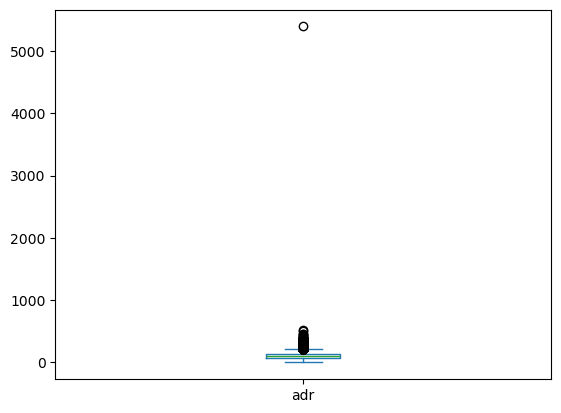

In [16]:
df['adr'].plot(kind='box')

In [17]:
# Remove negative adr values (invalid data)
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

## Data Visualization

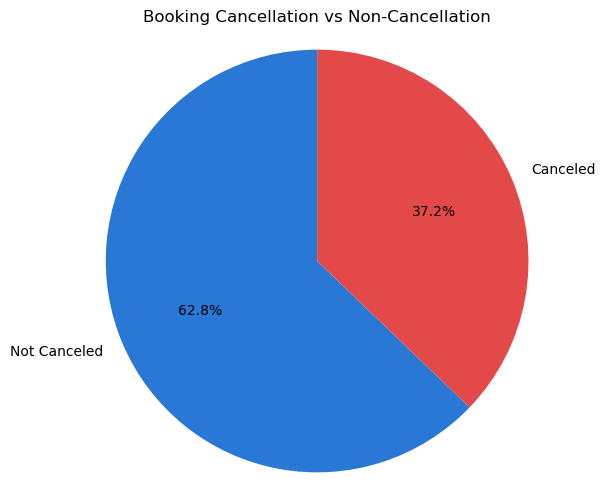

In [21]:
# Count values
cancel_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']
sizes = cancel_counts.values
colors = ['#2a78d6', '#e34948']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Booking Cancellation vs Non-Cancellation')
plt.axis('equal')  # keeps pie circular
plt.show()

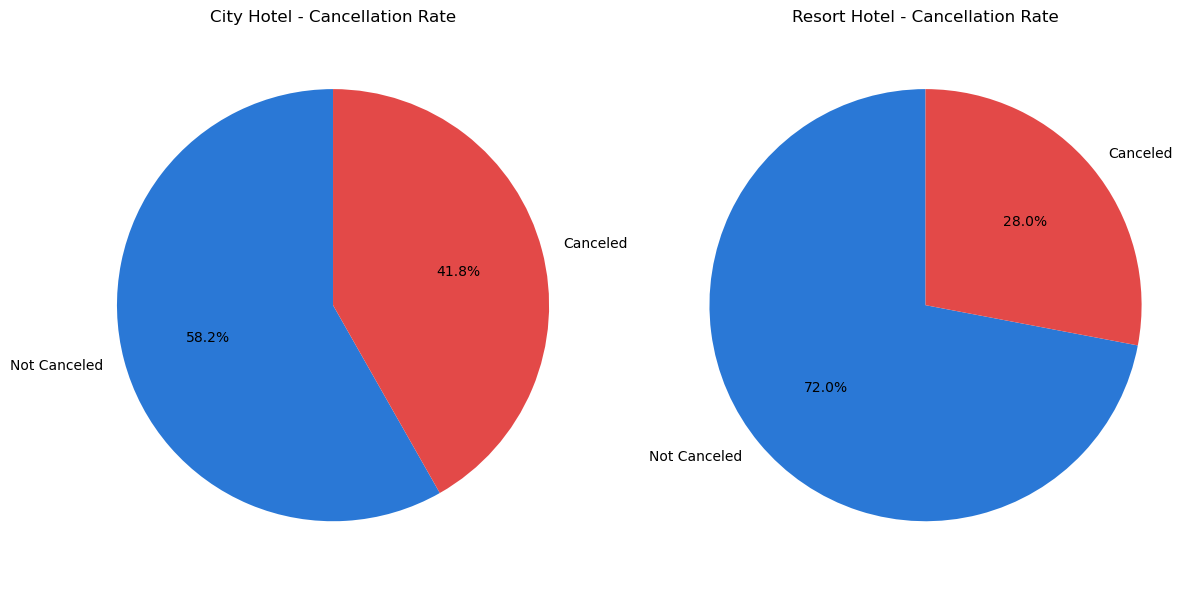

In [22]:
# Filter data by hotel type
city = df[df['hotel'] == 'City Hotel']['is_canceled'].value_counts()
resort = df[df['hotel'] == 'Resort Hotel']['is_canceled'].value_counts()

labels = ['Not Canceled', 'Canceled']
colors = ['#2a78d6', '#e34948']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# City Hotel pie chart
axes[0].pie(city.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('City Hotel - Cancellation Rate')
axes[0].axis('equal')

# Resort Hotel pie chart
axes[1].pie(resort.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Resort Hotel - Cancellation Rate')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

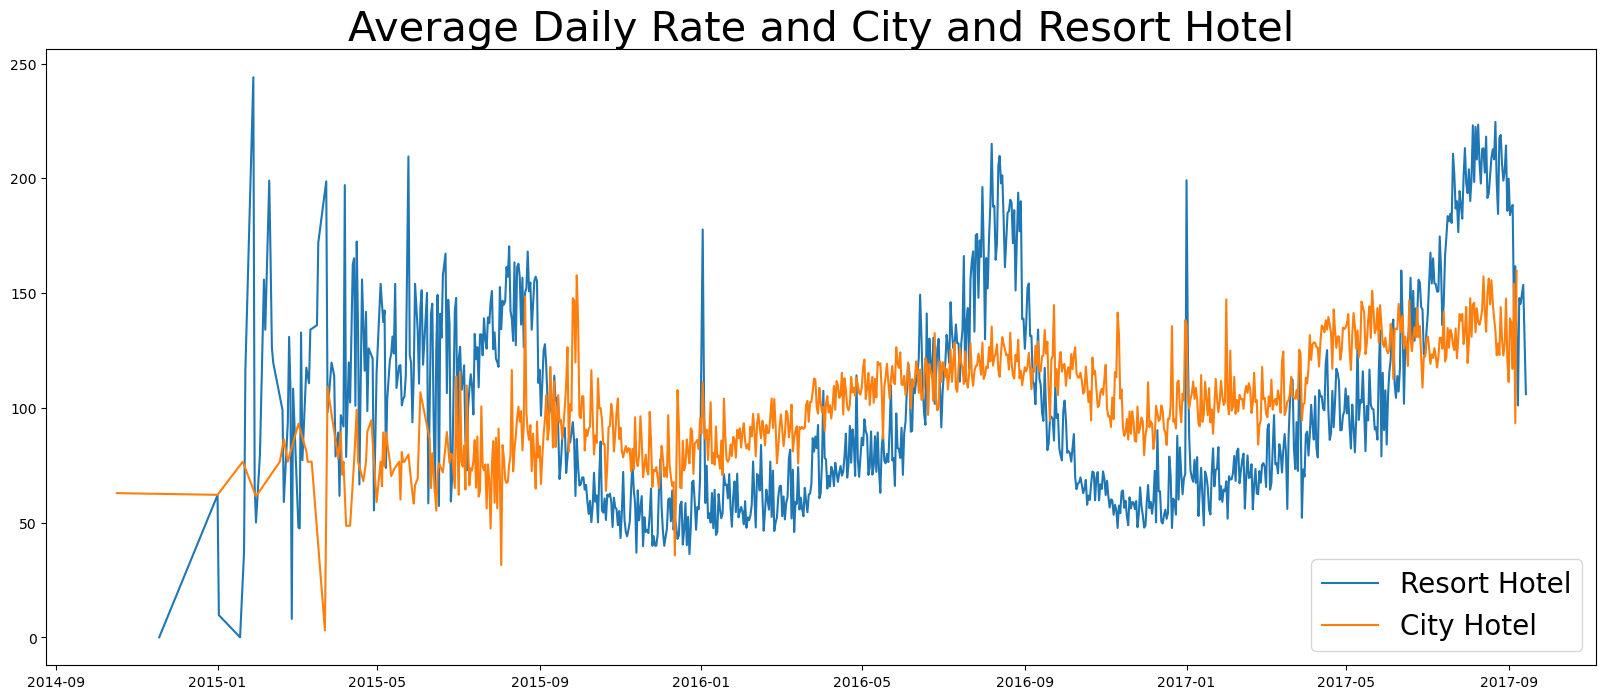

In [33]:
resort_hotel = df[df['hotel'] == 'Resort Hotel']
city_hotel = df[df['hotel'] == 'City Hotel']

resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean()


plt.figure(figsize=(20,8))
plt.title('Average Daily Rate and City and Resort Hotel', fontsize = 30)
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort Hotel')
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City Hotel')
plt.legend(fontsize = 20)
plt.show()

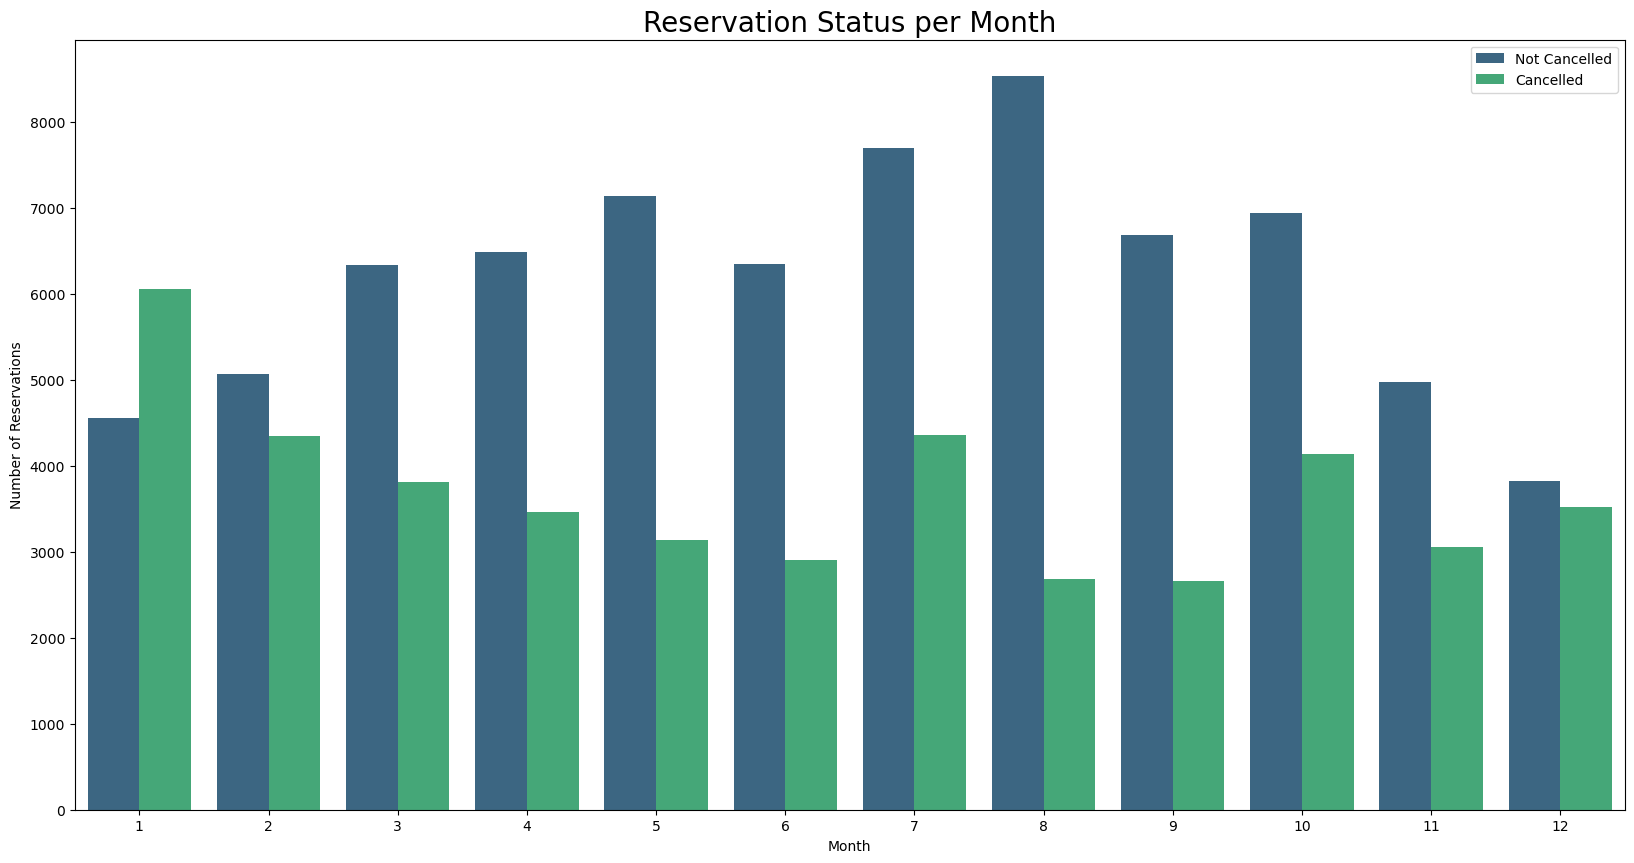

In [24]:
df['month'] = df['reservation_status_date'].dt.month

plt.figure(figsize=(20,10))

axl = sns.countplot(
    x='month',
    hue='is_canceled',
    data=df,
    palette='viridis'
)

axl.legend(['Not Cancelled', 'Cancelled'], bbox_to_anchor=(1,1))

plt.title('Reservation Status per Month', size=20)
plt.xlabel('Month')
plt.ylabel('Number of Reservations')

plt.show()

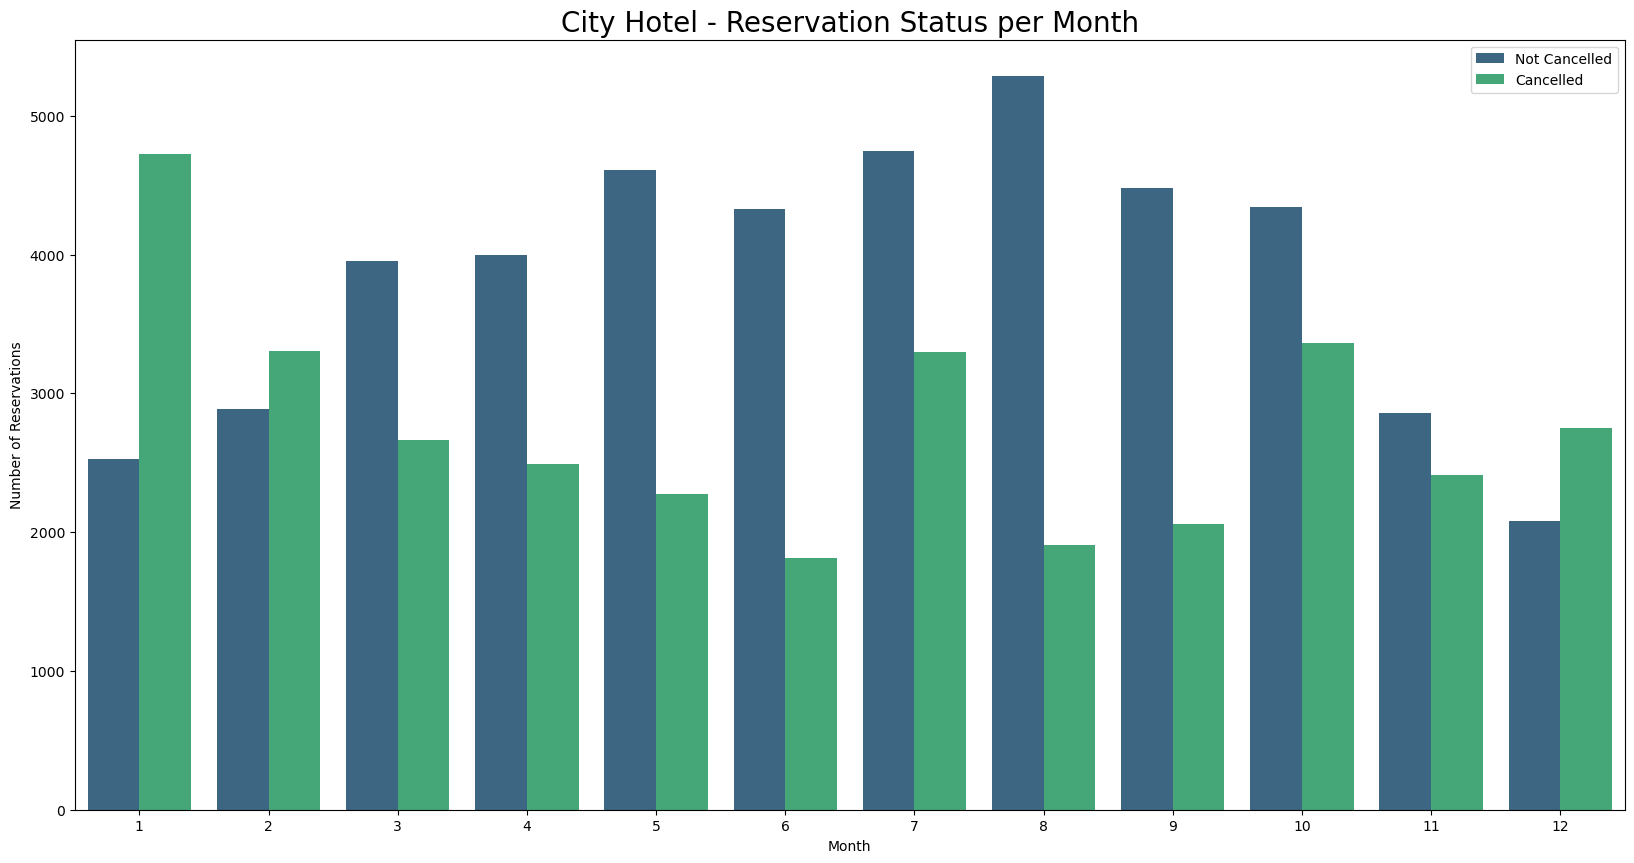

In [35]:
df['month'] = df['reservation_status_date'].dt.month

plt.figure(figsize=(20,10))
ax1 = sns.countplot(
    x='month',
    hue='is_canceled',
    data=df[df['hotel'] == 'City Hotel'],
    palette='viridis'
)
ax1.legend(['Not Cancelled', 'Cancelled'], bbox_to_anchor=(1,1))
plt.title('City Hotel - Reservation Status per Month', size=20)
plt.xlabel('Month')
plt.ylabel('Number of Reservations')
plt.show()

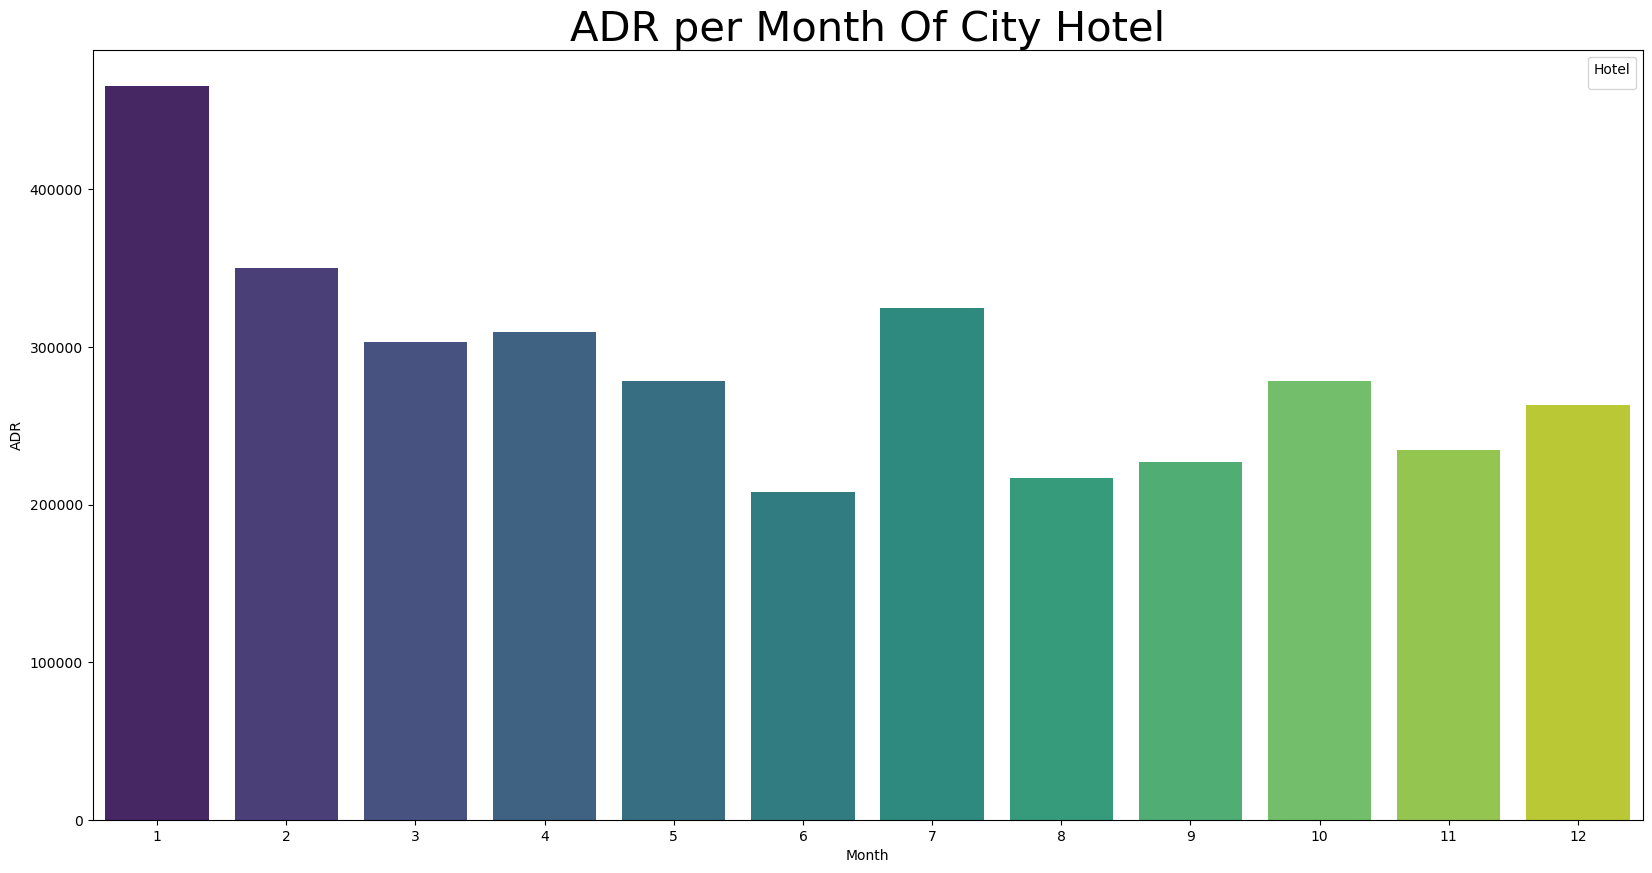

In [40]:
plt.figure(figsize=(20,10))
plt.title('ADR per Month Of City Hotel', fontsize=30)
sns.barplot(
    x='month',
    y='adr',
    data=df[(df['is_canceled'] == 1) & (df['hotel'] == 'City Hotel')]
        .groupby(['month', 'hotel'])[['adr']]
        .sum()
        .reset_index(),
    palette='viridis'
)
plt.xlabel('Month')
plt.ylabel('ADR')
plt.legend(title='Hotel')
plt.show()

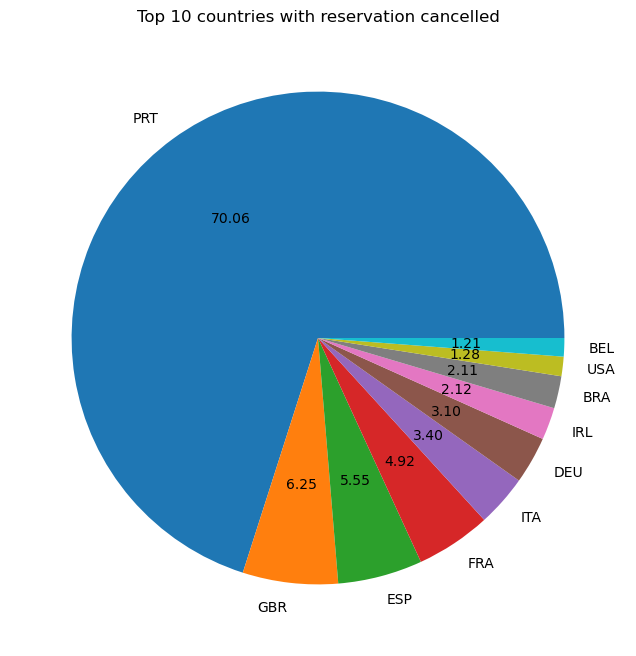

In [26]:
cancelled_data = df[df['is_canceled'] == 1]
top_10_country = cancelled_data['country'].value_counts()[:10]
plt.figure(figsize = (8,8))
plt.title('Top 10 countries with reservation cancelled')
plt.pie(top_10_country, autopct = '%.2f', labels = top_10_country.index)
plt.show()

In [27]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


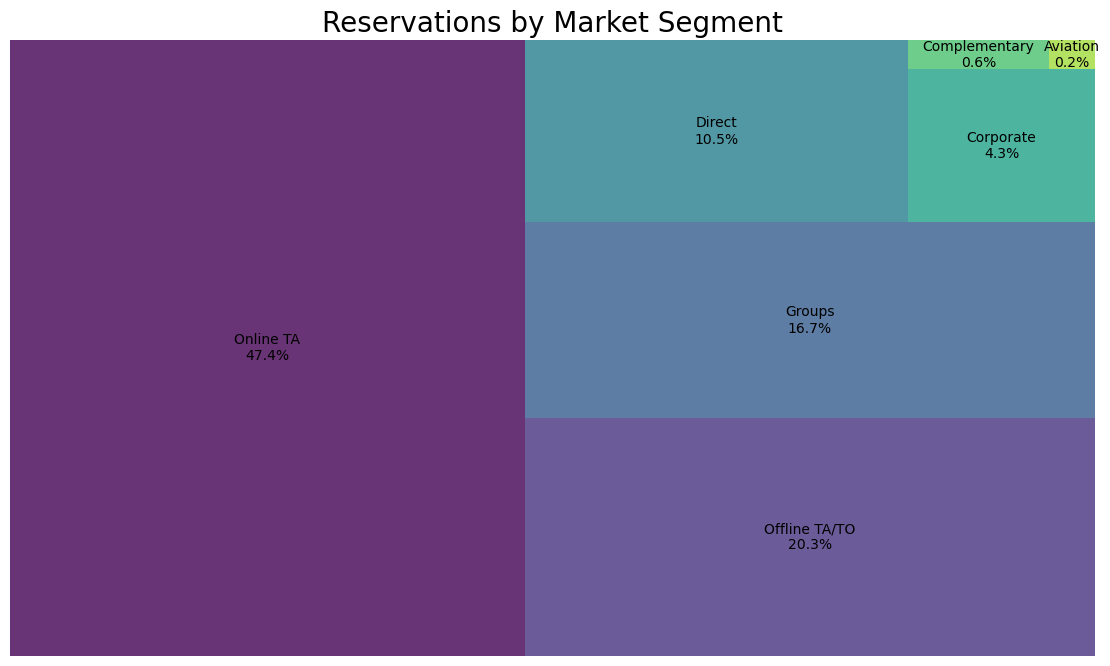

In [28]:
import squarify

market_counts = df['market_segment'].value_counts()
market_pct = df['market_segment'].value_counts(normalize=True) * 100

# Labels with only name and percentage
labels = [f'{name}\n{pct:.1f}%' 
          for name, pct in zip(market_counts.index, market_pct.values)]

plt.figure(figsize=(14, 8))
squarify.plot(sizes=market_counts.values, label=labels, alpha=0.8,
              color=plt.cm.viridis([i/len(market_counts) for i in range(len(market_counts))]))
plt.title('Reservations by Market Segment', fontsize=20)
plt.axis('off')
plt.show()

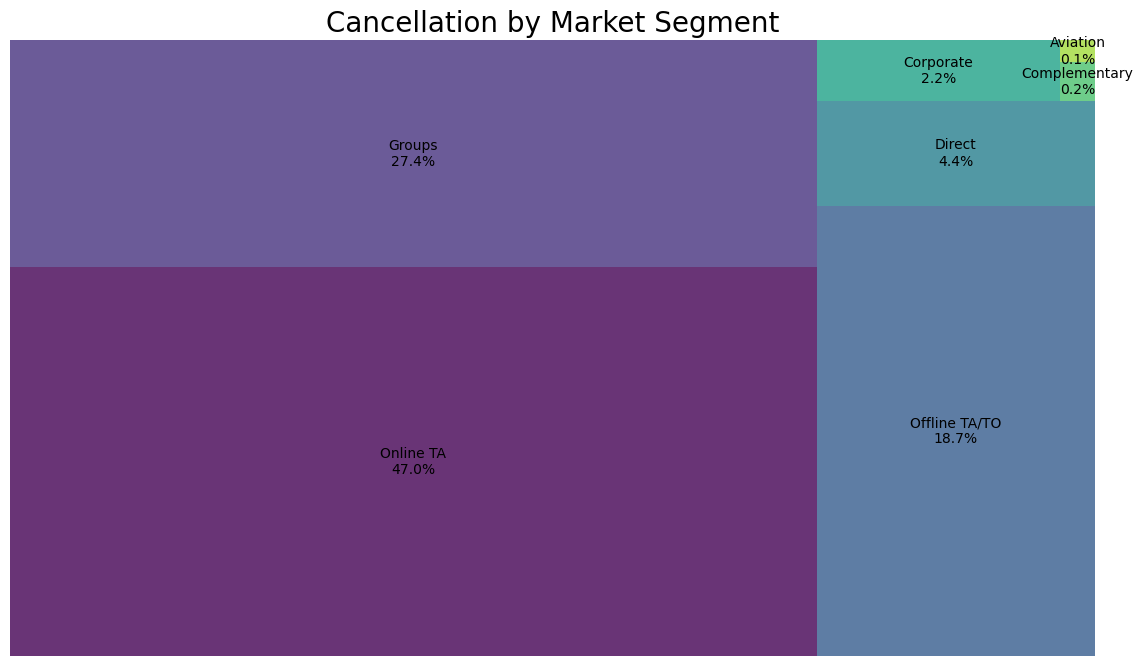

In [29]:
market_counts = cancelled_data['market_segment'].value_counts()
market_pct = cancelled_data['market_segment'].value_counts(normalize=True) * 100

# Labels with only name and percentage
labels = [f'{name}\n{pct:.1f}%' 
          for name, pct in zip(market_counts.index, market_pct.values)]

plt.figure(figsize=(14, 8))
squarify.plot(sizes=market_counts.values, label=labels, alpha=0.8,
              color=plt.cm.viridis([i/len(market_counts) for i in range(len(market_counts))]))
plt.title('Cancellation by Market Segment', fontsize=20)
plt.axis('off')
plt.show()

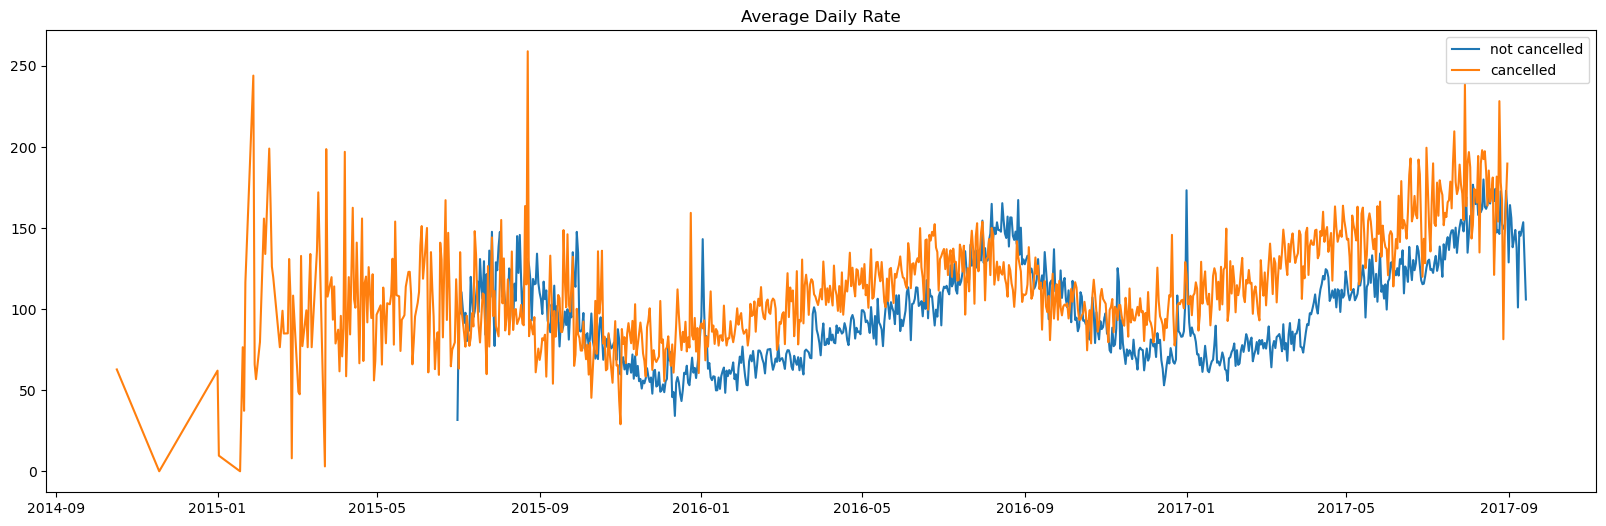

In [33]:
cancelled_df_adr = cancelled_data.groupby('reservation_status_date')[['adr']].mean()
cancelled_df_adr.reset_index(inplace=True)
cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

not_cancelled_data = df[df['is_canceled'] == 0]
not_cancelled_df_adr = not_cancelled_data.groupby('reservation_status_date')[['adr']].mean()
not_cancelled_df_adr.reset_index(inplace=True)
not_cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

plt.figure(figsize=(20, 6))
plt.title('Average Daily Rate')

plt.plot(
    not_cancelled_df_adr['reservation_status_date'],
    not_cancelled_df_adr['adr'],
    label='not cancelled'
)

plt.plot(
    cancelled_df_adr['reservation_status_date'],
    cancelled_df_adr['adr'],
    label='cancelled'
)

plt.legend()
plt.show()

In [34]:
cancelled_df_adr = cancelled_df_adr[(cancelled_df_adr['reservation_status_date']>'2016') & (cancelled_df_adr['reservation_status_date']<'2017-09')]
not_cancelled_df_adr = not_cancelled_df_adr[(not_cancelled_df_adr['reservation_status_date']>'2016') & (not_cancelled_df_adr['reservation_status_date']<'2017-09')]

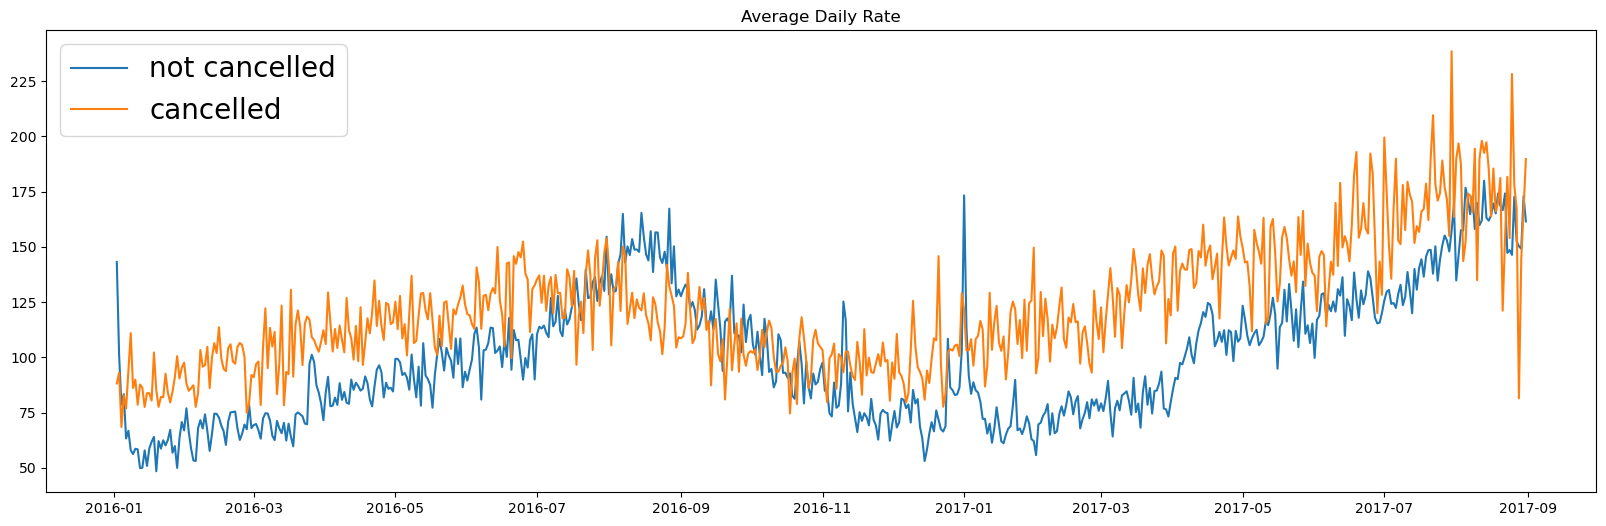

In [35]:
plt.figure(figsize=(20, 6))
plt.title('Average Daily Rate')

plt.plot(
    not_cancelled_df_adr['reservation_status_date'],
    not_cancelled_df_adr['adr'],
    label='not cancelled'
)

plt.plot(
    cancelled_df_adr['reservation_status_date'],
    cancelled_df_adr['adr'],
    label='cancelled'
)

plt.legend(fontsize=20)
plt.show()


# Suggestions

1. Cancellation rates rise as the price does. In order to prevent cancellations of reservations, hotels could work on their pricing strategies and try to lower the rates for specific hotels based on locations. They can also provide some discounts to the consumers.

2. As the ratio of the cancellation and not cancellation is higher in the city hotel than the resort hotels. So the hotels should provide a reasonable discount on the room prices on weekends or on holidays.

3. In the month of January, hotels can start campaigns or marketing with a reasonable amount to increase their revenue as the cancellation is the highest in this month.

4. They can also increase the quality of their hotels and their services mainly in Portugal to reduce the cancellation rate.